# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [3]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
# Load the prepared dataset from Phase 3
DATA_PATH = '../data/malicious_urls_prepared.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 21750 rows x 11 columns


,url_length,num_dots,num_slashes,num_digits,num_special_chars,has_ip,has_https,has_dash,num_subdomains,type,type_encoded
0,-1.175120,0.047578,-1.523403,-0.603078,-0.833366,0,0,1,0.047578,phishing,3
1,-0.654561,0.047578,-0.449670,-0.468595,-0.568620,0,0,0,0.047578,benign,0
2,-0.764152,0.047578,0.087197,-0.468595,-0.568620,0,0,0,0.047578,benign,0
3,0.797525,0.905737,0.087197,0.338305,1.152223,0,0,1,0.905737,defacement,1
4,3.866083,0.047578,0.087197,1.817621,0.622733,0,0,1,0.047578,defacement,1


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [5]:
# TODO: Select and document your modelling techniques here.


# Display the selected techniques
# print(f"Problem Type: {modelling_techniques['problem_type']}")
# print(f"Target Variable: {modelling_techniques['target_variable']}")
# print(f"\nCandidate Models:")
# for i, model in enumerate(modelling_techniques['candidate_models'], 1):
#     print(f"  {i}. {model['name']} — {model['justification']}")

# Modelling Techniques Selection

modelling_techniques = {
    "problem_type": "Multiclass Classification (Benign vs Phishing vs Malware vs Defacement)",

    "target_variable": "type_encoded",

    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": (
                "Serves as a baseline model for classification. It is simple, interpretable, "
                "and performs well when relationships between features and target are approximately linear."
            ),
            "assumptions": (
                "Assumes linear relationship between features and log-odds of the target. "
                "Features are scaled, so assumption is partially satisfied. May underperform if relationships are non-linear."
            )
        },
        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": (
                "Handles non-linear relationships and interactions between features effectively. "
                "Robust to noise and does not require strict assumptions about data distribution."
            ),
            "assumptions": (
                "Few strict assumptions. Works well with mixed feature types and does not require scaling. "
                "Suitable for this dataset due to non-linear patterns in URL structures."
            )
        },
        {
            "name": "Support Vector Machine (SVM)",
            "library": "sklearn.svm.SVC",
            "justification": (
                "Effective in high-dimensional spaces and can model complex decision boundaries using kernels. "
                "Useful for classification tasks with structured numerical features."
            ),
            "assumptions": (
                "Assumes data is separable (or approximately separable) in transformed feature space. "
                "Requires scaling, which has been applied. Can be computationally expensive for larger datasets."
            )
        },
        {
            "name": "Gradient Boosting (e.g., XGBoost or GradientBoostingClassifier)",
            "library": "sklearn.ensemble.GradientBoostingClassifier",
            "justification": (
                "Builds strong predictive models by combining weak learners. "
                "Captures complex patterns and interactions, often achieving high accuracy."
            ),
            "assumptions": (
                "Few strict assumptions. Handles non-linear relationships well. "
                "Sensitive to hyperparameters and may overfit if not tuned properly."
            )
        }
    ]
}

# Display
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}\n")

print("Candidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"{i}. {model['name']}")
    print(f"   Justification: {model['justification']}")
    print(f"   Assumptions: {model['assumptions']}\n")

Problem Type: Multiclass Classification (Benign vs Phishing vs Malware vs Defacement)
Target Variable: type_encoded

Candidate Models:
1. Logistic Regression
   Justification: Serves as a baseline model for classification. It is simple, interpretable, and performs well when relationships between features and target are approximately linear.
   Assumptions: Assumes linear relationship between features and log-odds of the target. Features are scaled, so assumption is partially satisfied. May underperform if relationships are non-linear.

2. Random Forest
   Justification: Handles non-linear relationships and interactions between features effectively. Robust to noise and does not require strict assumptions about data distribution.
   Assumptions: Few strict assumptions. Works well with mixed feature types and does not require scaling. Suitable for this dataset due to non-linear patterns in URL structures.

3. Support Vector Machine (SVM)
   Justification: Effective in high-dimensional spa

In [6]:
# Import the specific model classes you plan to use
# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier


---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [ ]:
# TODO: Define your test design and split the data.

RANDOM_SEED = 42
TEST_SIZE = 0.2

# Define features and target
X = df.drop(columns=['type', 'type_encoded'])
y = df['type_encoded']

# Stratified split (important for classification)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training set: 17400 samples
Test set:     4350 samples
Train class distribution:
type_encoded
0    0.695575
1    0.232701
3    0.050000
2    0.021724
Name: proportion, dtype: float64

Test class distribution:
type_encoded
0    0.695632
1    0.232644
3    0.049885
2    0.021839
Name: proportion, dtype: float64


In [11]:
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    
    "validation_strategy": "Hold-out validation with stratified sampling",
    
    "stratified": True,
    
    "random_seed": RANDOM_SEED,
    
    "justification": (
        "An 80/20 train-test split was chosen to ensure sufficient data for training "
        "while reserving a representative portion for unbiased evaluation. "
        "Stratified sampling was applied to maintain the original class distribution "
        "across training and test sets, which is important for multiclass classification. "
        "A fixed random seed ensures reproducibility of results. "
        "The hold-out method is appropriate given the dataset size and provides a simple, "
        "efficient evaluation strategy."
    )
}

print(f"Test Design:")
print(f"Split Ratio: {test_design['split_ratio']}")
print(f"Validation Strategy: {test_design['validation_strategy']}")
print(f"Stratified: {test_design['stratified']}")
print(f"Random Seed: {test_design['random_seed']}")
print(f"Justification: {test_design['justification']}") 

Test Design:
Split Ratio: 80/20
Validation Strategy: Hold-out validation with stratified sampling
Stratified: True
Random Seed: 42
Justification: An 80/20 train-test split was chosen to ensure sufficient data for training while reserving a representative portion for unbiased evaluation. Stratified sampling was applied to maintain the original class distribution across training and test sets, which is important for multiclass classification. A fixed random seed ensures reproducibility of results. The hold-out method is appropriate given the dataset size and provides a simple, efficient evaluation strategy.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [12]:
# TODO: Build and train your models.
# Store trained models in a dictionary for easy comparison.

trained_models = {}

# --- Model 1 ---
model_1 = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model_1.fit(X_train, y_train)
trained_models['Logistic Regression'] = model_1

# --- Model 2 ---
model_2 = RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100)
model_2.fit(X_train, y_train)
trained_models['Random Forest'] = model_2

# --- Model 3 ---
model_3 = GradientBoostingClassifier(random_state=RANDOM_SEED)
model_3.fit(X_train, y_train)
trained_models['Gradient Boosting'] = model_3

# --- Model 4 ---
model_4 = SVC(random_state=RANDOM_SEED)
model_4.fit(X_train, y_train)
trained_models['SVM'] = model_4

print(f"Successfully trained {len(trained_models)} model(s).")

Successfully trained 4 model(s).


In [13]:
# Optional: Hyperparameter tuning with GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score:   {grid_search.best_score_:.4f}")

trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best CV score:   0.8911


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [14]:
# TODO: Evaluate and compare all trained models.
# Build a results summary table.

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    # --- For Classification ---
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })


results_df = pd.DataFrame(results).set_index('Model').sort_values(by='F1-Score', ascending=False)

print("=== Model Comparison ===")
print(results_df.round(4))

=== Model Comparison ===
                       Accuracy  Precision  Recall  F1-Score
Model                                                       
Random Forest (Tuned)    0.8970     0.8950  0.8970    0.8922
Random Forest            0.8860     0.8832  0.8860    0.8839
Gradient Boosting        0.8890     0.8867  0.8890    0.8838
SVM                      0.8784     0.8756  0.8784    0.8714
Logistic Regression      0.7595     0.7175  0.7595    0.7176



=== Best Model: Random Forest (Tuned) ===

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      3026
           1       0.81      0.85      0.83      1012
           2       0.77      0.25      0.38        95
           3       0.84      0.64      0.72       217

    accuracy                           0.90      4350
   macro avg       0.84      0.67      0.72      4350
weighted avg       0.89      0.90      0.89      4350



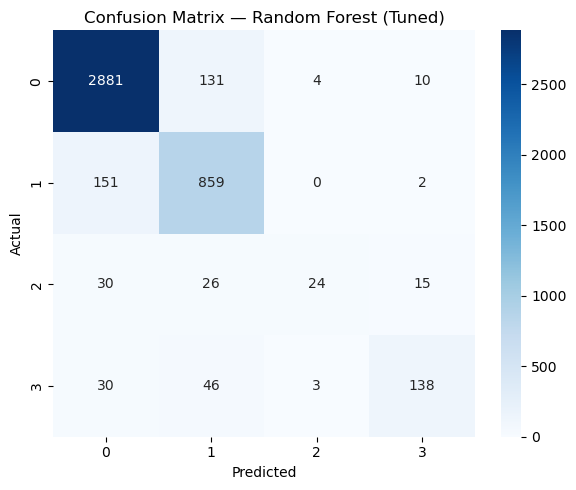

In [ ]:
# Visualise results: Confusion Matrix for the best model (Classification)

# Select best model
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [16]:
# Cross-validation for the selected best model



cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print("\n=== Cross-Validation ===")
print(f"F1 Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std:  {cv_scores.std():.4f}")


=== Cross-Validation ===
F1 Scores: [0.8985 0.8967 0.8931 0.8868 0.8835]
Mean: 0.8917
Std:  0.0057
